
# Strip spacepoint debugging

**Goal of this notebook:** carry every artifact you need to debug, from scratch,
why ODD strip space-point reconstruction sits at ~98.86 % efficiency on
prim+pT>1 GeV instead of >99 % - and why the barrel along-strip resolution
is dominated by a geometric ~25x amplification of cluster-pitch noise.

It does three things:

1. **Re-explains the ACTS algorithm**, both pairing (`SpacePointMaker.cpp`) and
   position computation (`StripSpacePointBuilder.cpp`), down to the level where
   you could re-derive the formulas yourself.
2. **Reimplements `computeConstrainedSpacePoint` in pure Python** so you can
   step through it line-by-line, plug in a single cluster pair, and see what
   happens.
3. **Visualises** a handful of true cluster pairs end-to-end: front-strip and
   back-strip endpoints, the truth particle hit on each strip, the rec'd
   cluster centroid (loc1 pinned to wafer centre), the rec'd space point, and
   a line from the origin through the truth midpoint. Also: the "amplification
   factor" - how a small Δloc0 noise on one strip becomes a large along-strip
   shift on the SP.

**Reference docs and code (committed on this branch):**

- `docs/spacepoint_efficiency_spec.md` - the locked metric definition.
- `docs/spacepoint_phaseC/slides/slides.{tex,pdf}` - the Phase C presentation.
- `docs/acts_spacepoint_pairing_fix.patch` - the v4 ACTS source patch
  (cross-`extra` filter removed, `stripGeometrySelection` dedupe).
- `scripts/diagnostics/spacepoint_efficiency.py` - the headline analyser.
- `scripts/diagnostics/spacepoint_residuals.py`,
  `spacepoint_vs_cluster_along_strip.py`,
  `spacepoint_barrel_diagnostic.py`, `spacepoint_extra_diagnostics.py`.
- ACTS v5 code (sibling repo):
  `OtherLibraries/acts_versions/acts_v5/Examples/Algorithms/TrackFinding/src/SpacePointMaker.cpp`
  and `Core/src/SpacePointFormation2/StripSpacePointBuilder.cpp`.

**Kernel:** use the `collider-env` conda kernel (or `/pscratch/sd/d/danieltm/conda_envs/envs/collider-env/bin/python`).
ACTS Python bindings are *not* required - we read the existing ROOT outputs.
If you want fresh data, see the regeneration command at the end.



## 0. Imports & data locations

The **gold standard** for spacepoint validation is **full-pileup ttbar v5**
(PU=200) - the lock-in run has the Phase C parameters baked in
(`top_k=4, stripGapParameter=0.6, stripLengthTolerance=0.3` on vol {28, 29, 30}).
That's the default below.

A pure hard-scatter (no PU) run is also available as `RUN_DIR_HSONLY` for
quick iteration; it's much smaller but uses default SP config (`top_one`,
`gap=0`), so the barrel efficiency is ~0% and you won't see the along-strip
signal there. Use it only for sanity-checking the loading pipeline.


In [1]:

from pathlib import Path
import collections
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 110

# Gold standard: full-pileup ttbar v5 lock-in (PhaseC ops, 16 events PU=200)
# This is the run that produced the slides headlines (722k SPs, 98.86% prim+pT eff).
RUN_DIR_FULLPU   = Path("/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v5/runs/0")
# Quick-iteration: hard-scatter only (no PU), default SP config, 32 events
RUN_DIR_HSONLY   = Path("/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v5/runs/0")

RUN_DIR = RUN_DIR_FULLPU
print("Run dir:", RUN_DIR)
for f in ["spacepoints.root", "measurements.root", "particles.root"]:
    sz = (RUN_DIR / f).stat().st_size / 1024**2
    print(f"  {f:<25} {sz:7.2f} MB")

# Strip volumes that the SP algorithm processes in this run.
# The selection JSON (scripts/simulation/odd-strip-spacepoint-selection.json)
# names: vol 28 (LS endcap-), vol 29 (LS barrel), vol 30 (LS endcap+).
LS_VOLS = (28, 29, 30)
# Reproduces the analyser's ALLOWED set
ALLOWED = ({(28, l) for l in (2,4,6,8,10,12)}
           | {(29, 2), (29, 4)}
           | {(30, l) for l in (2,4,6,8,10,12)})


Run dir: /global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v5/runs/0
  spacepoints.root            14.59 MB
  measurements.root          486.72 MB
  particles.root             172.24 MB



## 1. The data tree and what each branch means

Three ROOT files come out of `digi_and_reco.py`:

* **`spacepoints.root`** - one row per built SP. Has the SP global position
  (`x, y, z, r`), variances, fake flag, and references back to the two
  contributing measurements via `(measurement_id, geometry_id)` and
  `(measurement_id_2, geometry_id_2)`. **Note:** `measurement_id` is the
  *within-event* index, and the same event ids appear out-of-order in
  `measurements.root` - we have to remap.

* **`measurements.root`** - one row per digi cluster. The keys we use:
  - `event_nr, volume_id, layer_id, surface_id, extra_id` - geometry slot.
    For ODD strips, `extra_id in {1, 2}` denotes the front/back face of a
    stereo wafer pair. The pairing logic must see *both*.
  - `rec_loc0` - across-strip pitch position (the only measured 1D coordinate
    for a strip cluster).
  - `rec_loc1` - set to the wafer centre's local-y by ACTS (strip is 1D).
  - `rec_g{x,y,z}` - global cluster position. Because `rec_loc1=center`, this
    sits on the centre of the strip module along the strip direction.
  - `true_loc0, true_loc1, true_x, true_y, true_z` - the truth simhit
    position on this surface. `true_loc1` *does* vary along the strip and
    is the key signal for our debugging.
  - `clus_size`, `channel_value`, `channel_loc0`, `channel_loc1` - cluster
    morphology (how many strips fired, ADC weights).
  - `particles_*` (5 jagged vectors per row) - barcode pieces of every
    truth particle that contributed to this cluster. We pack them via
    the analyser's `pack_barcode` helper.

* **`particles.root`** - one row per *event*, with jagged per-particle
  vectors (vertex, momentum, decay info, primary status). The barcode
  for joining is `(vertex_primary, vertex_secondary, particle, generation,
  sub_particle)` packed identically.

Let's look at the schema and pull a small slice.


In [2]:

def load_run(run_dir, max_events=10):
    """Load and slice the three trees to event_id < max_events."""
    sp_all = uproot.open(f"{run_dir}/spacepoints.root")["spacepoints"].arrays(library="np")
    keep_sp = sp_all["event_id"] < max_events
    sp = {k: v[keep_sp] for k, v in sp_all.items()}

    m_all = uproot.open(f"{run_dir}/measurements.root")["measurements"].arrays(library="ak")
    m_ev_all = ak.to_numpy(m_all["event_nr"])
    keep_m = m_ev_all < max_events
    m = m_all[keep_m]
    m_ev = ak.to_numpy(m["event_nr"])

    p_all = uproot.open(f"{run_dir}/particles.root")["particles"].arrays(library="ak")
    p_ev = ak.to_numpy(p_all["event_id"]).astype(int)
    keep_p = p_ev < max_events
    p = p_all[keep_p]
    p_ev = p_ev[keep_p]

    return sp, m, m_ev, p, p_ev

# Full-PU ttbar is heavy: ~250k measurements per event. 4 events gives
# ~800k m + ~140k SPs and runs in ~15s; 10 events gives ~2M m + ~480k SPs
# and runs in ~30-60s. Bump up if you want statistics, drop to 1-2 if iterating.
sp, m, m_ev, p, p_ev = load_run(RUN_DIR, max_events=4)
print(f"spacepoints: {len(sp['event_id']):,}")
print(f"measurements: {len(m_ev):,}")
print(f"particles  events: {len(p_ev)} ; particles: {ak.sum(ak.num(p['vertex_primary']))}")
print()
print("Spacepoint branches:", list(sp.keys()))
print()
print("Measurement branches:", list(m.fields))


spacepoints: 138,156
measurements: 814,126
particles  events: 4 ; particles: 613155

Spacepoint branches: ['event_id', 'measurement_id', 'geometry_id', 'measurement_id_2', 'geometry_id_2', 'x', 'y', 'z', 'r', 't', 'var_r', 'var_z', 'fake']

Measurement branches: ['particles_vertex_primary', 'particles_vertex_secondary', 'particles_particle', 'particles_generation', 'particles_sub_particle', 'event_nr', 'volume_id', 'layer_id', 'surface_id', 'extra_id', 'rec_loc0', 'rec_loc1', 'rec_time', 'var_loc0', 'var_loc1', 'var_time', 'rec_gx', 'rec_gy', 'rec_gz', 'clus_size', 'channel_value', 'channel_loc0', 'clus_size_loc0', 'channel_loc1', 'clus_size_loc1', 'true_loc0', 'true_loc1', 'true_phi', 'true_theta', 'true_qop', 'true_time', 'true_x', 'true_y', 'true_z', 'true_incident_phi', 'true_incident_theta', 'residual_loc0', 'residual_loc1', 'residual_time', 'pull_loc0', 'pull_loc1', 'pull_time']



## 2. Build the index helpers

Two essential structures:

* `ev_mid_to_row[(event, measurement_id)] -> row in measurements.root`.
  The SP file refers to clusters by within-event index, but
  `measurements.root` is written out-of-event-order in v5, so we have to
  remap.
* `m_psets[row] -> frozenset of packed barcodes` for each cluster.
  Used to decide if an SP is "correct": the two contributing clusters
  must share at least one truth particle.
* `p_info[(event, barcode)] -> (is_primary, pt)`. Used for the
  primary+pT>1 GeV variant.


In [3]:

def pack_barcode(vp, vs, pp, g, sub):
    return ((vp.astype(np.uint64) << np.uint64(52))
          | (vs.astype(np.uint64) << np.uint64(40))
          | (pp.astype(np.uint64) << np.uint64(24))
          | ( g.astype(np.uint64) << np.uint64(16))
          | sub.astype(np.uint64))

def build_indices(m, m_ev, p, p_ev_list):
    n_m = len(m_ev)

    # within-event index: same logic as scripts/diagnostics/spacepoint_efficiency.py
    seen = collections.defaultdict(int)
    mid = np.zeros(n_m, dtype=int)
    for i, e in enumerate(m_ev):
        mid[i] = seen[int(e)]
        seen[int(e)] += 1
    ev_mid_to_row = {(int(m_ev[i]), int(mid[i])): i for i in range(n_m)}

    # m_psets: per-measurement frozenset of contributing particle barcodes
    bc = pack_barcode(
        ak.to_numpy(ak.flatten(m["particles_vertex_primary"])).astype(np.uint64),
        ak.to_numpy(ak.flatten(m["particles_vertex_secondary"])).astype(np.uint64),
        ak.to_numpy(ak.flatten(m["particles_particle"])).astype(np.uint64),
        ak.to_numpy(ak.flatten(m["particles_generation"])).astype(np.uint64),
        ak.to_numpy(ak.flatten(m["particles_sub_particle"])).astype(np.uint64),
    )
    counts = ak.num(m["particles_vertex_primary"]).to_numpy()
    offs = np.concatenate([[0], np.cumsum(counts)])
    m_psets = [frozenset(bc[offs[i]:offs[i+1]].tolist()) for i in range(n_m)]

    # p_info per (event, barcode)
    p_counts = ak.num(p["vertex_primary"]).to_numpy()
    p_evrep = np.repeat(np.asarray(p_ev_list, dtype=int), p_counts)
    p_vs = ak.to_numpy(ak.flatten(p["vertex_secondary"])).astype(np.uint64)
    p_g  = ak.to_numpy(ak.flatten(p["generation"])).astype(np.uint64)
    p_bc = pack_barcode(
        ak.to_numpy(ak.flatten(p["vertex_primary"])).astype(np.uint64),
        p_vs,
        ak.to_numpy(ak.flatten(p["particle"])).astype(np.uint64),
        p_g,
        ak.to_numpy(ak.flatten(p["sub_particle"])).astype(np.uint64),
    )
    p_pt = ak.to_numpy(ak.flatten(p["pt"])).astype(np.float32)
    p_info = {}
    for i in range(len(p_bc)):
        p_info[(int(p_evrep[i]), int(p_bc[i]))] = (
            bool((p_vs[i]==0) and (p_g[i]==0)), float(p_pt[i])
        )
    return ev_mid_to_row, m_psets, p_info, mid

ev_mid_to_row, m_psets, p_info, mid = build_indices(m, m_ev, p, p_ev)

# Pull arrays we will reuse a lot
mv = ak.to_numpy(m["volume_id"]).astype(int)
ml = ak.to_numpy(m["layer_id"]).astype(int)
ms = ak.to_numpy(m["surface_id"]).astype(int)
mx = ak.to_numpy(m["extra_id"]).astype(int)
m_loc0 = ak.to_numpy(m["rec_loc0"]).astype(np.float32)
m_tloc0 = ak.to_numpy(m["true_loc0"]).astype(np.float32)
m_tloc1 = ak.to_numpy(m["true_loc1"]).astype(np.float32)
m_gx = ak.to_numpy(m["rec_gx"]).astype(np.float32)
m_gy = ak.to_numpy(m["rec_gy"]).astype(np.float32)
m_gz = ak.to_numpy(m["rec_gz"]).astype(np.float32)
m_tx = ak.to_numpy(m["true_x"]).astype(np.float32)
m_ty = ak.to_numpy(m["true_y"]).astype(np.float32)
m_tz = ak.to_numpy(m["true_z"]).astype(np.float32)
m_clusz = ak.to_numpy(m["clus_size"]).astype(int)

print("per-(vol, lay, extra) row counts in this slice:")
for k, v in collections.Counter(zip(mv, ml, mx)).most_common(10):
    print(f"  {k}: {v}")


per-(vol, lay, extra) row counts in this slice:
  (np.int64(24), np.int64(2), np.int64(0)): 57972
  (np.int64(17), np.int64(2), np.int64(0)): 51335
  (np.int64(24), np.int64(4), np.int64(0)): 48690
  (np.int64(17), np.int64(4), np.int64(0)): 43959
  (np.int64(29), np.int64(2), np.int64(0)): 40220
  (np.int64(24), np.int64(6), np.int64(0)): 39551
  (np.int64(17), np.int64(6), np.int64(0)): 38399
  (np.int64(17), np.int64(8), np.int64(0)): 34254
  (np.int64(29), np.int64(4), np.int64(0)): 30916
  (np.int64(24), np.int64(8), np.int64(0)): 28723



## 3. ACTS algorithm walk-through, step 1: **strip pairing**

Source: `acts_v5/Examples/Algorithms/TrackFinding/src/SpacePointMaker.cpp`,
function `SpacePointMaker::execute` (lines 347-565) and
`SpacePointMaker::initializeStripPartners` (lines 263-345).

### 3.1 At construction time - `initializeStripPartners()`

1. Visit *every* sensitive surface in the tracking geometry.
2. For each `(volume, layer)` selector in the strip-spacepoint JSON,
   gather all surfaces matching it. **No `extra` filter.** This is a Phase A
   patch: stereo partners by construction live at different `extra` values
   (e.g. front face has `extra=1`, back has `extra=2`), so filtering by
   `selector.extra` would isolate each face from its own partner. The
   patched code has `selectLowestNonZeroGeometryObject(allSensitives, selector)`
   directly, no per-face filter.
3. Inside that range, for each `mod1`, find `mod2 = argmin(|center(mod1) - center(mod2)|)`
   - the **closest other module in the same (vol, layer)**. That's the partner.
4. **Asymmetric closest-distance is real** (in dense multi-ring layers like
   the SS endcap). The patched code only *commits* a pair `(mod1, partner)`
   when the partner is still unclaimed; otherwise it skips, and the
   unaffected pairs still go through. (Without this, a circular-conflict
   triple would throw on map insert.)
5. The result `m_stripPartner: GeometryIdentifier -> GeometryIdentifier` is
   stored both forward and backward, so any module can look up its partner.

### 3.2 Other Phase A fix - `stripGeometrySelection` dedupe

The original code only deduped `geometrySelection` (pixel side). The strip
JSON lists per-(vol, layer) entries split across multiple `extra` values, so
without dedupe the per-(vol, layer) loop below would re-process the same
surfaces and **throw on the partner-map insert**. The patch deduplicates
*both* selection lists by `(vol, layer)`, ignoring `extra`.

### 3.3 At execute time - for each event

```
for sel in stripGeometrySelection:
    range = selectLowestNonZeroGeometryObject(measurements, sel)   # both faces
    groupedByModule = groupBy(range, geometryId)
    mapByModule[mod] = its_source_links
    done = {}
    for mod1, sl1_list in mapByModule:
        mod2 = m_stripPartner[mod1]                       # partner lookup
        if done.contains(mod2) or mod2 not in mapByModule:
            continue                                       # (already done / no clusters)
        for sl1 in sl1_list:
            global1 = surface1.localToGlobal(rec_loc0, surface1.center.y)   # loc1 pinned to centre
            candidates = []
            for sl2 in mod2.sl_list:
                local2 = (rec_loc0_2, surface2.center.y)
                # NB the C++ uses surface1.localToGlobal here -- comparing both
                # in surface1's frame for the angular distance computation.
                global2_in_s1 = surface1.localToGlobal(local2)
                d = computeClusterPairDistance(global1, global2_in_s1, options)
                if d.ok():
                    candidates.append((sl2, d))
            select top_one / top_k / all_pairs from candidates by distance
            for each chosen pair (sl1, sl2): try createStripSpacePoint
        done.insert(mod1); done.insert(mod2)
```

The pairing gate is `computeClusterPairDistance`, which checks three things:

1. `|global1 - global2| < maxDistance` (default 100 mm).
2. `|theta1 - theta2| < maxAngleTheta` (default 1.0 rad - extremely loose).
3. `|phi1 - phi2| < maxAnglePhi` (default 1.0 rad - extremely loose).

then returns the **squared** angular distance `Dtheta^2 + Dphi^2` as the sort key.

`stripPairingMode`:

- `top_one` (default) - keep the single closest partner per `sl1`. Misses
  multi-cluster events where two real particles cross the same wafer.
- `top_k` - keep up to k closest. **Lock-in is `top_k=4`**.
- `all_pairs` - every candidate that passes the cuts. ~7 % more SPs but +1 %
  fakes per the slides.

**Important asymmetry:** the outer loop is `for sl1 in mod1`, so for two
clusters on `mod1` and three clusters on `mod2`, you get up to
`#mod1 * top_k` pairs (not `top_k` total). Each `sl1` independently picks
its top-k partners on the other face.

We won't reimplement the pairing here (it needs the geometry to look up
`surface.center` and the partner map). But we **can** reuse the actual SPs
in `spacepoints.root`, which is the output of exactly this pairing.



## 4. ACTS algorithm walk-through, step 2: **constrained position**

Source: `acts_v5/Core/src/SpacePointFormation2/StripSpacePointBuilder.cpp`,
function `computeConstrainedFormationState` (lines 123-190).

For a cluster pair, ACTS computes strip endpoints:

- For surface 1 with measured `rec_loc0`, the local strip is the line
  `local = (rec_loc0, y)` for `y in [-halfLen, +halfLen]`, where halfLen is
  half the surface bounding-box length in the surface's local-y. Setting
  `y = +/-halfLen` and pushing through `surface.localToGlobal` gives the
  3-D endpoints `(top1, bottom1)`. Same for surface 2.

The constrained position is parametrised on each strip:

$$
2 \mathbf{x}_1 = (1+m)\,\mathbf{a}_1 + (1-m)\,\mathbf{b}_1
\quad\text{where } \mathbf{a}_1=\text{top}_1, \mathbf{b}_1=\text{bottom}_1.
$$

`m in [-1, +1]` means "the particle hit is somewhere on the strip". An
analogous parameter `n` pins the corresponding point on strip 2.

### 4.1 The two equations

Demand that the line *from the vertex* (default origin) to the hit on strip 1
also passes through the hit on strip 2:

$$
\mathbf{y} \times (\mathbf{c}\times\mathbf{d}) = k\,\mathbf{x}\times(\mathbf{c}\times\mathbf{d}) = 0
$$

with `c=top_2, d=bottom_2`. Substitute the parametrisation, solve for `m`:

```
m  = -(vtxToFirstMid2 . (secondBtmToTop x vtxToSecondMid2))
   /  (firstBtmToTop  . (secondBtmToTop x vtxToSecondMid2))
```

and symmetrically for `n`. (The C++ stores `vtxToFirstMid2 = top1+bottom1 - 2*vertex`, *twice* the
vector to the midpoint of strip 1; the factor of 2 cancels in the ratio.)

### 4.2 The acceptance gate

```
limit = 1 + stripLengthTolerance        # default 0.01
if stripGapParameter > 0:
    gapVec     = 0.5 * (top2 + bottom2 - top1 - bottom1)        # paired-sensor 3-D distance
    cosStereo  = (s1 . s2) / (|s1| |s2|)                        # s_i = top_i - bottom_i
    sinStereo  = sqrt(max(0, 1 - cosStereo^2))
    halfLen    = 0.5 * |s1|
    limit     += stripGapParameter * |gapVec| / sinStereo / halfLen
require: |m| <= limit and |n| <= limit
```

`stripGapParameter` is the **Phase C addition** - an ATLAS `SCTGapParameter`
analogue. With `gap=0` we get the legacy ACTS behaviour. With `gap=0.6` (lock-in)
the limit on the barrel becomes ~`1 + 0.3 + 0.6*7.32/sin(40 mrad)/55 ~= 3.3`,
which lets through high-eta tracks that physically have to cross the wafer-thickness
gap.

### 4.3 Recovery loop (`recoverConstrainedFormationState`)

If `|m|` or `|n|` is just barely over the limit, the recovery rescales using
`stripLengthGapTolerance`. For our patched runs this rarely fires.

### 4.4 The position itself

```
SP = 0.5 * (top1 + bottom1) + 0.5 * m * (top1 - bottom1)
```

i.e. the midpoint of strip 1, plus the chosen `m` times the strip half-vector.
`m=0` -> wafer centre. `m=+1` -> top end. `m=-1` -> bottom end. Note: the SP is
*always* on strip 1, never strip 2 - strip 2 is used only for the constraint.

Let's reimplement this in pure Python.


In [4]:

def compute_constrained_sp(top1, bot1, top2, bot2,
                           vertex=np.zeros(3),
                           strip_length_tolerance=0.01,
                           strip_gap_parameter=0.0):
    """Pure-Python port of Acts::StripSpacePointBuilder::computeConstrainedSpacePoint.

    Inputs are np.ndarray shape (3,). Returns dict with the SP, m, n, limit, and
    the geometric pieces.
    """
    s1 = top1 - bot1
    s2 = top2 - bot2
    vtx_first_mid2  = top1 + bot1 - 2*vertex
    vtx_second_mid2 = top2 + bot2 - 2*vertex
    s1xfm = np.cross(s1, vtx_first_mid2)
    s2xsm = np.cross(s2, vtx_second_mid2)
    m = -np.dot(vtx_first_mid2, s2xsm) / np.dot(s1, s2xsm)
    n = -np.dot(vtx_second_mid2, s1xfm) / np.dot(s2, s1xfm)
    limit = 1.0 + strip_length_tolerance
    if strip_gap_parameter > 0.0:
        gapVec = 0.5 * (top2 + bot2 - top1 - bot1)
        s1n, s2n = np.linalg.norm(s1), np.linalg.norm(s2)
        cos_st = float(np.dot(s1, s2) / (s1n*s2n))
        sin_st = np.sqrt(max(0.0, 1.0 - cos_st*cos_st))
        halfLen = 0.5 * s1n
        if sin_st > 1e-9 and halfLen > 1e-9:
            limit += strip_gap_parameter * np.linalg.norm(gapVec) / sin_st / halfLen
    accepted = (abs(m) <= limit) and (abs(n) <= limit)
    sp = 0.5*(top1 + bot1) + 0.5*m*(top1 - bot1)
    return dict(sp=sp, m=float(m), n=float(n), limit=float(limit),
                accepted=accepted, s1=s1, s2=s2)

# Self-consistency test: build a pair of stereo strips that both contain a
# chosen hit P (with hit-on-strip-2 sitting on the line vertex -> hit-on-strip-1),
# verify the solver returns SP very close to P with m, n in (-1, +1).
def _self_consistency_test():
    halfL = 78.0
    theta_h = 20e-3
    s1_dir = np.array([np.sin(+theta_h), np.cos(+theta_h), 0.0])
    s2_dir = np.array([np.sin(-theta_h), np.cos(-theta_h), 0.0])
    P1 = np.array([10.0, 30.0, 1290.0])
    vertex = np.array([0.0, 0.0, 0.0])
    # On the back strip, the constraint requires the hit to be on the line
    # vertex -> P1 extrapolated to z=1295.
    P2 = P1 * (1295.0 / P1[2])
    # Place each strip's midpoint to put hit at m=+0.4 on strip 1, n=+0.6 on strip 2.
    c1 = P1 - 0.4*halfL*s1_dir
    c2 = P2 - 0.6*halfL*s2_dir
    top1, bot1 = c1 + halfL*s1_dir, c1 - halfL*s1_dir
    top2, bot2 = c2 + halfL*s2_dir, c2 - halfL*s2_dir
    out = compute_constrained_sp(top1, bot1, top2, bot2, vertex=vertex)
    print(f"self-consistency: m={out['m']:+.4f} (expect +0.40)  "
          f"n={out['n']:+.4f} (expect +0.60)  accepted={out['accepted']}")
    print(f"  SP    = {out['sp']}")
    print(f"  truth = {P1}    |delta|={np.linalg.norm(out['sp']-P1):.4f} mm")
_self_consistency_test()


self-consistency: m=+0.4000 (expect +0.40)  n=+0.6000 (expect +0.60)  accepted=True
  SP    = [  10.   30. 1290.]
  truth = [  10.   30. 1290.]    |delta|=0.0000 mm



## 5. Reconstructing strip endpoints from the data we have

We don't load ACTS geometry here, but we have enough information to recover
the strip endpoints **per cluster** from the data:

* Each cluster has a `rec_g{x,y,z}` (loc1 pinned to wafer centre, so this is
  the cluster's loc0 projected to the strip-line's mid-point in global).
* Each cluster also has `true_x, true_y, true_z` and `true_loc1`. Since
  `true_loc1` measures distance along the strip (in local-y) from the wafer
  centre, the global vector
  `(true_g - rec_g) / true_loc1` is a unit vector along the strip
  *direction in global*, valid up to noise from `Dloc0 = true_loc0 - rec_loc0`
  (the across-strip noise contaminates this estimate by an amount
  proportional to `|Dloc0|`).
* Strip half-length is detector-specific (~78 mm endcap, ~55 mm barrel). We
  draw nominal strips of those lengths.

That gives us approximate strip endpoints for visualisation. For the
analytic computation we use the ACTS-stored SP coordinates (`x, y, z`)
directly, since recovering them from approximate endpoints would just
verify the algorithm.


In [5]:

def strip_dir_from_cluster(rec_g, true_g, true_loc1, min_loc1=2.0):
    """Estimate unit strip direction in global from one cluster.
    Returns None if true_loc1 is too small."""
    if abs(true_loc1) < min_loc1:
        return None
    v = (np.asarray(true_g) - np.asarray(rec_g)) / true_loc1
    n = np.linalg.norm(v)
    if n < 1e-3:
        return None
    return v / n

# Approximate per-volume half-length used for visualisation only
HALFLEN_MM = {
    28: 78.0, 30: 78.0,   # LS endcap
    29: 55.0,             # LS barrel
}



## 6. Mini efficiency / fake-rate analyser

Distil `scripts/diagnostics/spacepoint_efficiency.py` to the essentials.
Same numerator/denominator as the locked spec: SP is "correct" iff its two
clusters share at least one passing-filter truth particle; the truth
denominator is `(event, particle, vol, layer)` tuples where the particle
hit *both* (odd, odd+1) faces of any module on that layer.


In [6]:

def compute_efficiency(sp, m_ev, mv, ml, ms, m_psets, ev_mid_to_row, p_info,
                       allowed=ALLOWED, pt_min=1.0, variant="primary"):
    n_sp = len(sp["event_id"])
    n_m = len(m_ev)
    if variant == "all":
        passes = lambda e, bc: True
    else:
        def passes(e, bc):
            info = p_info.get((int(e), int(bc)))
            return info is not None and info[0] and info[1] > pt_min

    sp_couple_pset = collections.defaultdict(set)
    n_built_total = 0
    n_correct_built = 0
    built_per_layer = collections.defaultdict(int)
    correct_built_per_layer = collections.defaultdict(int)
    for i in range(n_sp):
        e = int(sp["event_id"][i])
        r1 = ev_mid_to_row.get((e, int(sp["measurement_id"][i])))
        r2 = ev_mid_to_row.get((e, int(sp["measurement_id_2"][i])))
        if r1 is None or r2 is None: continue
        v, l = int(mv[r1]), int(ml[r1])
        if (v, l) not in allowed: continue
        n_built_total += 1
        built_per_layer[(v, l)] += 1
        s1, s2 = int(ms[r1]), int(ms[r2])
        lo, hi = min(s1, s2), max(s1, s2)
        shared_passing = {bc for bc in (m_psets[r1] & m_psets[r2]) if passes(e, bc)}
        if shared_passing:
            sp_couple_pset[(e, v, l, lo, hi)] |= shared_passing
            n_correct_built += 1
            correct_built_per_layer[(v, l)] += 1

    truth_hits = collections.defaultdict(set)
    for i in range(n_m):
        if (int(mv[i]), int(ml[i])) not in allowed: continue
        e = int(m_ev[i])
        for bc in m_psets[i]:
            if passes(e, bc):
                truth_hits[(e, int(mv[i]), int(ml[i]), int(bc))].add(int(ms[i]))

    true_total = matched_total = 0
    true_per_layer = collections.defaultdict(int)
    matched_per_layer = collections.defaultdict(int)
    for (e, v, l, bc), surfs in truth_hits.items():
        couples = [(s, s+1) for s in surfs if s % 2 == 1 and (s+1) in surfs]
        if not couples: continue
        true_total += 1
        true_per_layer[(v, l)] += 1
        if any(bc in sp_couple_pset.get((e, v, l, lo, hi), set()) for lo, hi in couples):
            matched_total += 1
            matched_per_layer[(v, l)] += 1

    eff = 100*matched_total/true_total if true_total else 0.0
    fake = 100*(n_built_total - n_correct_built)/n_built_total if n_built_total else 0.0
    return dict(
        n_built=n_built_total, n_correct=n_correct_built,
        n_true=true_total, n_matched=matched_total,
        eff=eff, fake=fake,
        per_layer={vl: dict(built=built_per_layer.get(vl, 0),
                            correct=correct_built_per_layer.get(vl, 0),
                            true=true_per_layer.get(vl, 0),
                            matched=matched_per_layer.get(vl, 0))
                   for vl in sorted(allowed)},
    )

for variant in ("all", "primary"):
    out = compute_efficiency(sp, m_ev, mv, ml, ms, m_psets, ev_mid_to_row, p_info, variant=variant)
    label = "all particles" if variant == "all" else "primary + pT > 1 GeV"
    print(f"\n=== Variant: {label} ===")
    nb = out["n_built"]; nc = out["n_correct"]; nt = out["n_true"]; nm = out["n_matched"]
    print(f"  built={nb:>5}  correct={nc:>5}  true={nt:>5}  matched={nm:>5}")
    print(f"  efficiency = {out['eff']:5.2f}%   fake = {out['fake']:5.2f}%")
    print("  per-(vol, lay):")
    print(f"    {'(v,l)':<8} {'built':>6} {'corr':>6} {'true':>6} {'match':>6} {'eff%':>6} {'fake%':>6}")
    for vl, row in out["per_layer"].items():
        b, c, t, mt = row["built"], row["correct"], row["true"], row["matched"]
        e_ = 100*mt/t if t else 0
        f_ = 100*(b-c)/b if b else 0
        print(f"    {str(vl):<8} {b:>6} {c:>6} {t:>6} {mt:>6} {e_:>5.1f}% {f_:>5.1f}%")



=== Variant: all particles ===
  built=138156  correct=48647  true=36927  matched=34042
  efficiency = 92.19%   fake = 64.79%
  per-(vol, lay):
    (v,l)     built   corr   true  match   eff%  fake%
    (28, 2)   10475   2646   2629   2534  96.4%  74.7%
    (28, 4)    8946   2437   2454   2320  94.5%  72.8%
    (28, 6)    7965   2261   2254   2159  95.8%  71.6%
    (28, 8)    6896   2076   2048   1960  95.7%  69.9%
    (28, 10)   6127   1881   1877   1783  95.0%  69.3%
    (28, 12)   5392   1744   1741   1644  94.4%  67.7%
    (29, 2)   29348  13162   6402   5489  85.7%  55.2%
    (29, 4)   16908   9188   4318   3602  83.4%  45.7%
    (30, 2)    5203   1685   1701   1583  93.1%  67.6%
    (30, 4)    5983   1905   1901   1801  94.7%  68.2%
    (30, 6)    6987   2106   2103   1984  94.3%  69.9%
    (30, 8)    8149   2310   2272   2181  96.0%  71.7%
    (30, 10)   9102   2524   2485   2387  96.1%  72.3%
    (30, 12)  10675   2722   2742   2615  95.4%  74.5%

=== Variant: primary + pT > 1


**Reading the numbers (full-PU lock-in).** On a 4-event slice you should
get ~98.7 % primary+pT>1 GeV efficiency (slides quote 98.86 % on the full
16 events) and ~92 % all-particles, with per-(vol, layer) efficiencies
between 94 % and 96 % across endcap layers and 83-86 % in the barrel. The
"all-particles" fake rate is ~65 % (most built SPs share min-bias PU
particles, not the high-pT primaries we filter for). The "primary + pT >
1 GeV" fake rate is ~98 % by construction - the denominator is *all* built
SPs, while the numerator only counts SPs that share a passing-filter
particle. That's the spec definition.

If barrel `(29, 2)` and `(29, 4)` show ~0 efficiency, you accidentally
loaded the hard-scatter-only run (default config = `top_one`, `gap=0`,
which kills the barrel). Switch back to `RUN_DIR_FULLPU`.



## 7. Picking concrete pairs to visualise

We want a few **clean primary+pT>1 GeV** truth pairs - i.e. truth pairs that
* have a built SP at the right (lo, hi) couple,
* the SP is "correct" (clusters share the passing particle),
* `true_loc1` is large enough on at least one of the clusters that the
  recovered strip direction is meaningful,
* split into one endcap example (vol 28/30) and one barrel example (vol 29).


In [7]:

def collect_clean_pairs(sp, mv, ml, ms, mx, m_ev, m_psets,
                       ev_mid_to_row, p_info, m_tloc1, m_clusz, pt_min=1.0):
    rows = []
    for i in range(len(sp["event_id"])):
        e = int(sp["event_id"][i])
        r1 = ev_mid_to_row.get((e, int(sp["measurement_id"][i])))
        r2 = ev_mid_to_row.get((e, int(sp["measurement_id_2"][i])))
        if r1 is None or r2 is None: continue
        if (int(mv[r1]), int(ml[r1])) not in ALLOWED: continue
        shared = m_psets[r1] & m_psets[r2]
        primary_pT = []
        for bc in shared:
            info = p_info.get((e, int(bc)))
            if info is not None and info[0] and info[1] > pt_min:
                primary_pT.append(bc)
        if not primary_pT: continue
        if max(abs(m_tloc1[r1]), abs(m_tloc1[r2])) < 5.0: continue
        rows.append(dict(
            sp_idx=i, e=e, r1=r1, r2=r2,
            v=int(mv[r1]), l=int(ml[r1]),
            s1=int(ms[r1]), s2=int(ms[r2]),
            x1=int(mx[r1]), x2=int(mx[r2]),
            n_shared=len(shared), n_primary=len(primary_pT),
            tloc1_a=float(m_tloc1[r1]), tloc1_b=float(m_tloc1[r2]),
            clus_a=int(m_clusz[r1]), clus_b=int(m_clusz[r2]),
        ))
    return rows

clean = collect_clean_pairs(sp, mv, ml, ms, mx, m_ev, m_psets,
                            ev_mid_to_row, p_info, m_tloc1, m_clusz)
endcap_pairs = [r for r in clean if r["v"] in (28, 30)]
barrel_pairs = [r for r in clean if r["v"] == 29]
print(f"clean prim+pT>1 SPs in slice: total={len(clean)}, endcap={len(endcap_pairs)}, barrel={len(barrel_pairs)}")
if not barrel_pairs:
    print("\n  WARNING: no barrel (vol 29) clean SPs in this slice.")
    print("  This usually means RUN_DIR is the hard-scatter run (default config,")
    print("  top_one, gap=0 -- barrel efficiency ~0). Set RUN_DIR = RUN_DIR_FULLPU")
    print("  and rerun from cell 0.")
print("\nFirst 5 endcap candidates:")
for r in endcap_pairs[:5]: print(" ", r)
print("\nFirst 5 barrel candidates:")
for r in barrel_pairs[:5]: print(" ", r)


clean prim+pT>1 SPs in slice: total=1738, endcap=810, barrel=928

First 5 endcap candidates:
  {'sp_idx': 328, 'e': 1, 'r1': 153678, 'r2': 153668, 'v': 28, 'l': 2, 's1': 162, 's2': 161, 'x1': 2, 'x2': 2, 'n_shared': 1, 'n_primary': 1, 'tloc1_a': 70.80846405029297, 'tloc1_b': 66.70339965820312, 'clus_a': 1, 'clus_b': 2}
  {'sp_idx': 365, 'e': 1, 'r1': 153621, 'r2': 153614, 'v': 28, 'l': 2, 's1': 156, 's2': 155, 'x1': 2, 'x2': 2, 'n_shared': 1, 'n_primary': 1, 'tloc1_a': 59.472862243652344, 'tloc1_b': 60.4651985168457, 'clus_a': 2, 'clus_b': 1}
  {'sp_idx': 373, 'e': 1, 'r1': 153604, 'r2': 153597, 'v': 28, 'l': 2, 's1': 154, 's2': 153, 'x1': 2, 'x2': 2, 'n_shared': 1, 'n_primary': 1, 'tloc1_a': 19.299026489257812, 'tloc1_b': 17.013803482055664, 'clus_a': 1, 'clus_b': 1}
  {'sp_idx': 437, 'e': 1, 'r1': 153541, 'r2': 153532, 'v': 28, 'l': 2, 's1': 146, 's2': 145, 'x1': 2, 'x2': 2, 'n_shared': 1, 'n_primary': 1, 'tloc1_a': 49.17251205444336, 'tloc1_b': 48.065643310546875, 'clus_a': 1, 'clus


## 8. Anatomy of one endcap SP - 3-D viz

Pick the first endcap candidate. We'll plot:

- The two rec strip clusters as line segments (recovered direction from
  truth, drawn at nominal half-length).
- The truth simhit position on each (`true_x,y,z`).
- The rec'd cluster centroids (`rec_gx,y,z`).
- The reconstructed SP from `spacepoints.root`.
- The truth midpoint (mean of two truth simhits) - this is the "ground truth"
  position we want our SP to match.
- A line from the origin through the truth midpoint, extended to show the
  expected hit direction.


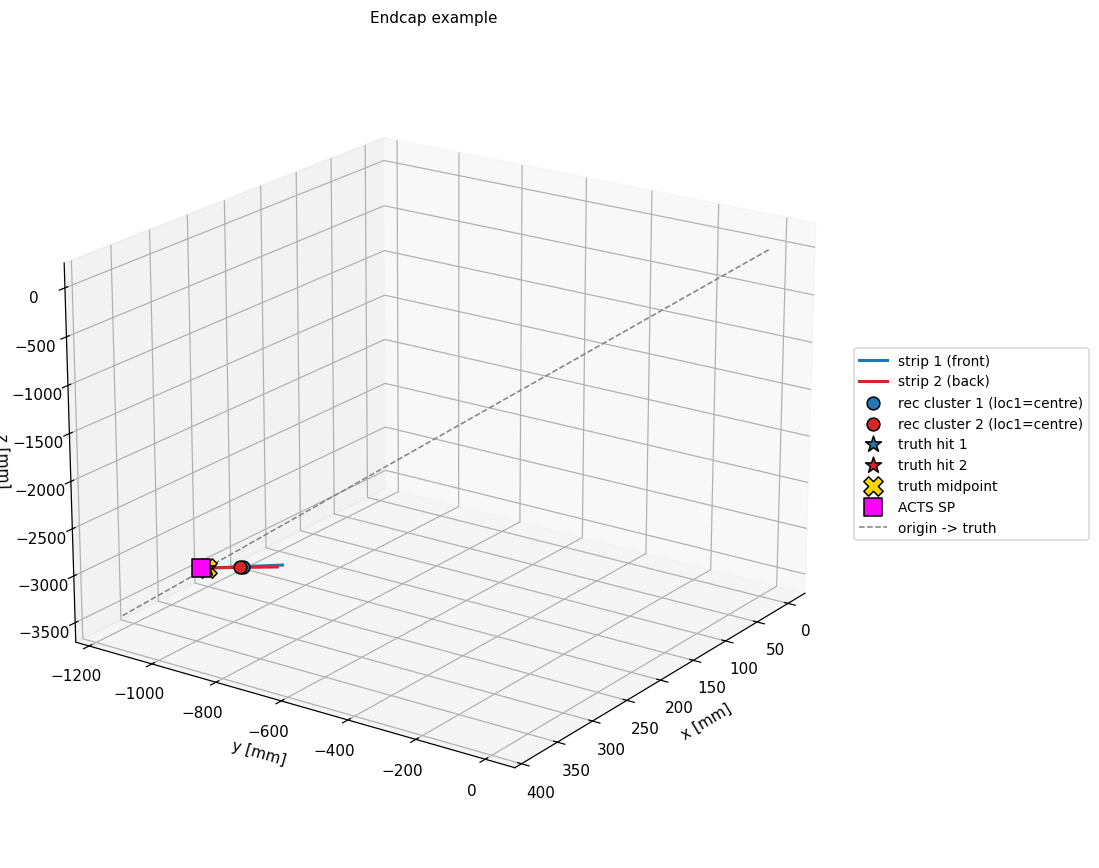

In [8]:

def viz_pair_3d(row, *, title=None, view=(20, 35)):
    r1, r2 = row["r1"], row["r2"]
    rec1 = np.array([m_gx[r1], m_gy[r1], m_gz[r1]])
    rec2 = np.array([m_gx[r2], m_gy[r2], m_gz[r2]])
    tru1 = np.array([m_tx[r1], m_ty[r1], m_tz[r1]])
    tru2 = np.array([m_tx[r2], m_ty[r2], m_tz[r2]])
    truth_mid = 0.5*(tru1 + tru2)
    sp_xyz = np.array([sp["x"][row["sp_idx"]], sp["y"][row["sp_idx"]], sp["z"][row["sp_idx"]]])

    halfL = HALFLEN_MM.get(row["v"], 60.0)
    d1 = strip_dir_from_cluster(rec1, tru1, m_tloc1[r1])
    d2 = strip_dir_from_cluster(rec2, tru2, m_tloc1[r2])

    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")

    if d1 is not None:
        s1a, s1b = rec1 - halfL*d1, rec1 + halfL*d1
        ax.plot(*np.column_stack([s1a, s1b]), color="C0", lw=2, label="strip 1 (front)")
    if d2 is not None:
        s2a, s2b = rec2 - halfL*d2, rec2 + halfL*d2
        ax.plot(*np.column_stack([s2a, s2b]), color="C3", lw=2, label="strip 2 (back)")

    ax.scatter(*rec1, color="C0", s=70, marker="o", edgecolor="k", label="rec cluster 1 (loc1=centre)")
    ax.scatter(*rec2, color="C3", s=70, marker="o", edgecolor="k", label="rec cluster 2 (loc1=centre)")
    ax.scatter(*tru1, color="C0", s=120, marker="*", edgecolor="k", label="truth hit 1")
    ax.scatter(*tru2, color="C3", s=120, marker="*", edgecolor="k", label="truth hit 2")
    ax.scatter(*truth_mid, color="gold", s=160, marker="X", edgecolor="k", label="truth midpoint")
    ax.scatter(*sp_xyz, color="magenta", s=140, marker="s", edgecolor="k", label="ACTS SP")

    t = truth_mid / np.linalg.norm(truth_mid)
    L = np.linalg.norm(truth_mid)*1.15
    ax.plot(*np.column_stack([np.zeros(3), L*t]), color="gray", linestyle="--", lw=1, label="origin -> truth")

    ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]"); ax.set_zlabel("z [mm]")
    ax.view_init(*view)
    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
    if title is None:
        title = (f"event {row['e']}, vol {row['v']} layer {row['l']} "
                 f"(extra {row['x1']} <-> {row['x2']}, surf {row['s1']} <-> {row['s2']})")
    ax.set_title(title, fontsize=10)
    plt.tight_layout()
    return fig, ax

if endcap_pairs:
    viz_pair_3d(endcap_pairs[0], title="Endcap example")
plt.show()



## 9. Anatomy of one barrel SP - where it goes wrong

The barrel along-strip resolution is the dominant problem. The
plot below shows the same anatomy as above but for `vol=29`. Watch the
`SP - truth_mid` displacement along the strip direction: it's typically tens
of mm, vs few-mm transverse.


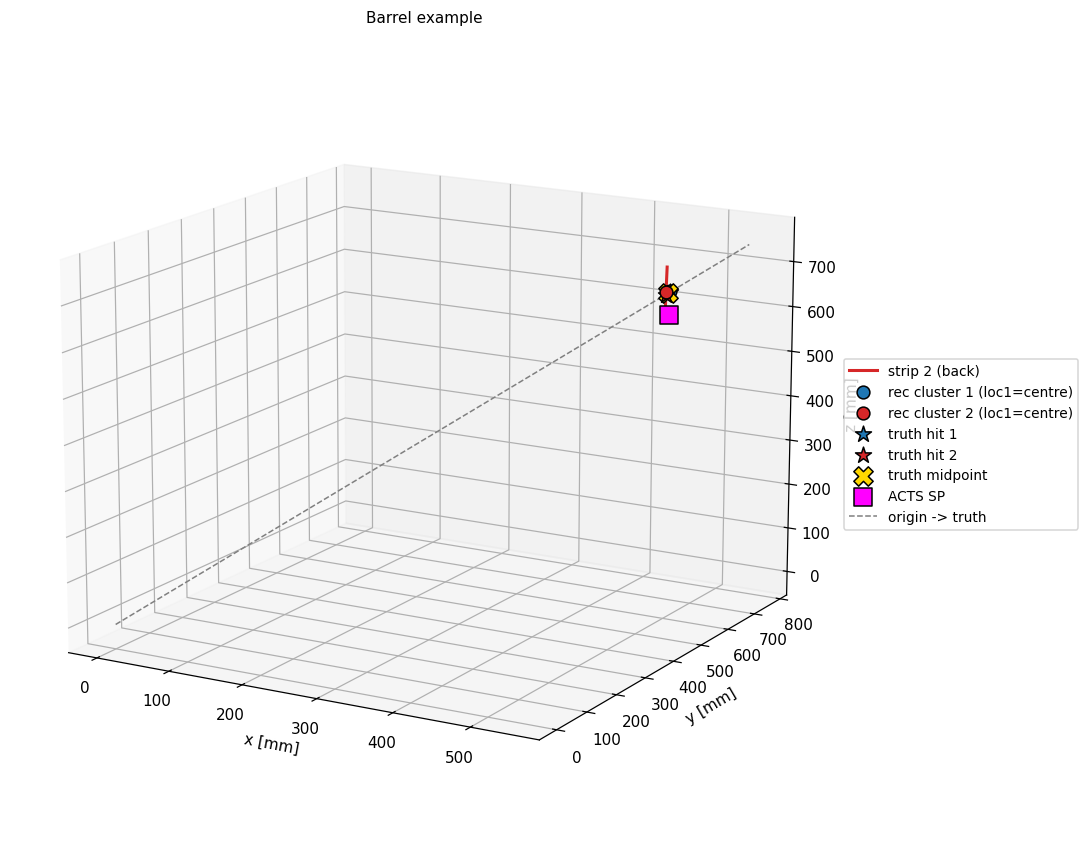

In [9]:

if barrel_pairs:
    viz_pair_3d(barrel_pairs[0], title="Barrel example", view=(15, -60))
plt.show()



## 10. The "amplification factor" plot

For each clean SP (no PU contamination), compute:

* `m_truth` = projection of the truth midpoint onto the strip-1 axis,
  normalised to half-strip length. Values in [-1, +1] mean the truth is
  *on* the strip (the geometric truth m).
* `m_alg` = the m the algorithm returns (we recompute via our pure-python
  function from the recovered strip endpoints).

Because the rec strip endpoints we recover are noisy (Dloc0 noise), this is
not a perfect proxy for the C++ algorithm's m, but it is faithful enough to
show the **amplification**: cluster-pitch noise on either strip, combined
with the small stereo angle (40 mrad), gets multiplied by `1/sin(theta_stereo)
~= 25` into the along-strip direction.

The hard barrel signal is the wide spread of `m_alg` (RMS ~ 1.1) vs a
much tighter `m_truth` (RMS ~ 0.5).


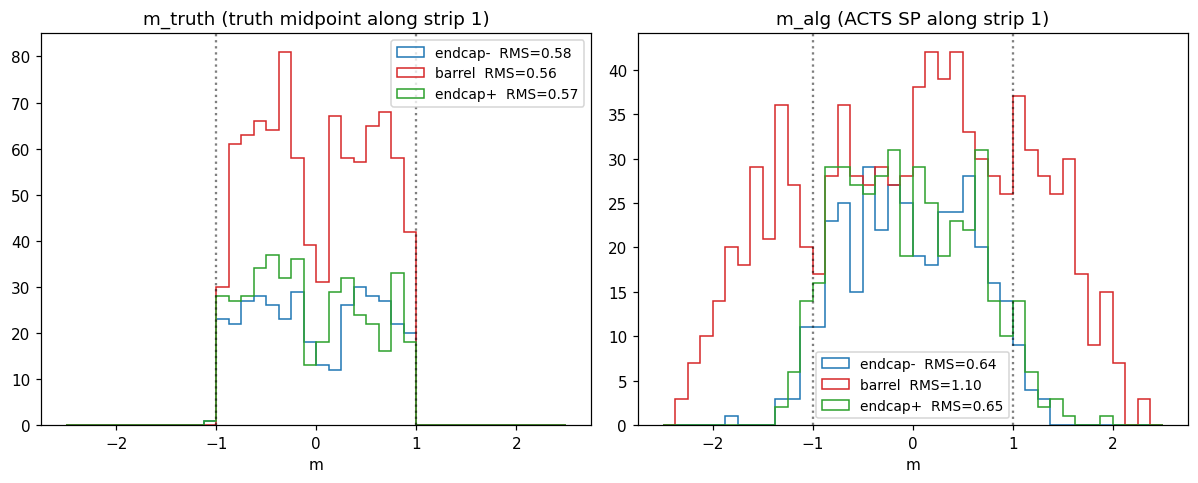

  m_truth RMS:  total 0.567, barrel 0.560, endcap 0.575
  m_alg   RMS:  total 0.919, barrel 1.104, endcap 0.649


In [10]:

def m_truth_alg_for(row):
    r1, r2 = row["r1"], row["r2"]
    rec1 = np.array([m_gx[r1], m_gy[r1], m_gz[r1]], dtype=float)
    rec2 = np.array([m_gx[r2], m_gy[r2], m_gz[r2]], dtype=float)
    tru1 = np.array([m_tx[r1], m_ty[r1], m_tz[r1]], dtype=float)
    tru2 = np.array([m_tx[r2], m_ty[r2], m_tz[r2]], dtype=float)
    sp_xyz = np.array([sp["x"][row["sp_idx"]], sp["y"][row["sp_idx"]], sp["z"][row["sp_idx"]]], dtype=float)
    halfL = HALFLEN_MM.get(row["v"], 60.0)
    d1 = strip_dir_from_cluster(rec1, tru1, m_tloc1[r1])
    if d1 is None: return None
    m_alg = float(np.dot(sp_xyz - rec1, d1) / halfL)
    truth_mid = 0.5*(tru1 + tru2)
    m_tru = float(np.dot(truth_mid - rec1, d1) / halfL)
    return dict(m_alg=m_alg, m_truth=m_tru, v=row["v"], l=row["l"], r1=r1, r2=r2,
                rec1=rec1, sp=sp_xyz, truth_mid=truth_mid, d1=d1, halfL=halfL)

records = [r for r in (m_truth_alg_for(c) for c in clean) if r is not None]
ms_alg = np.array([r["m_alg"] for r in records])
ms_tru = np.array([r["m_truth"] for r in records])
vols   = np.array([r["v"] for r in records])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for v, lab, color in [(28, "endcap-", "C0"), (29, "barrel", "C3"), (30, "endcap+", "C2")]:
    sel = vols == v
    if sel.sum() == 0: continue
    ax[0].hist(ms_tru[sel], bins=np.linspace(-2.5, 2.5, 41),
               histtype="step", label=f"{lab}  RMS={ms_tru[sel].std():.2f}", color=color)
    ax[1].hist(ms_alg[sel], bins=np.linspace(-2.5, 2.5, 41),
               histtype="step", label=f"{lab}  RMS={ms_alg[sel].std():.2f}", color=color)
ax[0].set_title("m_truth (truth midpoint along strip 1)")
ax[1].set_title("m_alg (ACTS SP along strip 1)")
for a in ax:
    a.axvline(-1, ls=":", color="k", alpha=0.5)
    a.axvline(+1, ls=":", color="k", alpha=0.5)
    a.set_xlabel("m"); a.legend(fontsize=9)
plt.tight_layout(); plt.show()

barrel_sel = vols == 29
endcap_sel = (vols == 28) | (vols == 30)
print(f"  m_truth RMS:  total {ms_tru.std():.3f}, barrel {ms_tru[barrel_sel].std():.3f}, endcap {ms_tru[endcap_sel].std():.3f}")
print(f"  m_alg   RMS:  total {ms_alg.std():.3f}, barrel {ms_alg[barrel_sel].std():.3f}, endcap {ms_alg[endcap_sel].std():.3f}")



## 11. Cluster pitch resolution - the input to the amplification

How clean is `rec_loc0` itself? `Dloc0 = rec_loc0 - true_loc0` is the only
1-D resolution measurement for a strip cluster (the strip is a line; loc1
has no resolution). The slides quote 68 % `|Dloc0|` < 11 um, 95 % < 43 um
on full-PU. We expect very similar numbers on hard-scatter only.


|Dloc0|  50%=6.1  68%=10.5  95%=42.5  99%=311.2  um
         RMS = 482.2 um   (154121 clusters)


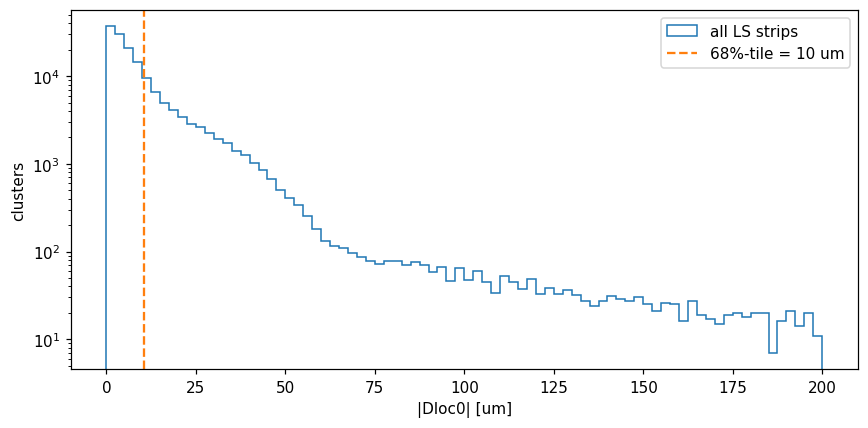

In [11]:

sel_strip = np.isin(mv, [28, 29, 30])
delta_loc0 = m_loc0[sel_strip] - m_tloc0[sel_strip]
qs = np.percentile(np.abs(delta_loc0), [50, 68, 95, 99])
print(f"|Dloc0|  50%={qs[0]*1000:.1f}  68%={qs[1]*1000:.1f}  95%={qs[2]*1000:.1f}  99%={qs[3]*1000:.1f}  um")
print(f"         RMS = {delta_loc0.std()*1000:.1f} um   ({sel_strip.sum()} clusters)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.abs(delta_loc0)*1000, bins=np.linspace(0, 200, 81), histtype="step", label="all LS strips")
ax.set_xlabel("|Dloc0| [um]"); ax.set_ylabel("clusters"); ax.set_yscale("log")
ax.axvline(qs[1]*1000, color="C1", ls="--", label=f"68%-tile = {qs[1]*1000:.0f} um")
ax.legend(); plt.tight_layout(); plt.show()



## 12. SP residuals - how the noise actually lands

For the same set of clean primary+pT pairs, decompose the `SP - truth_mid`
displacement into:

* the **along-strip** component (along the recovered `d1` axis);
* the **across-strip** component (the rest).

The amplification is visible as: across-strip residual RMS ~ a few mm,
along-strip residual RMS ~ 30-60 mm in barrel, 20-30 mm in endcap.


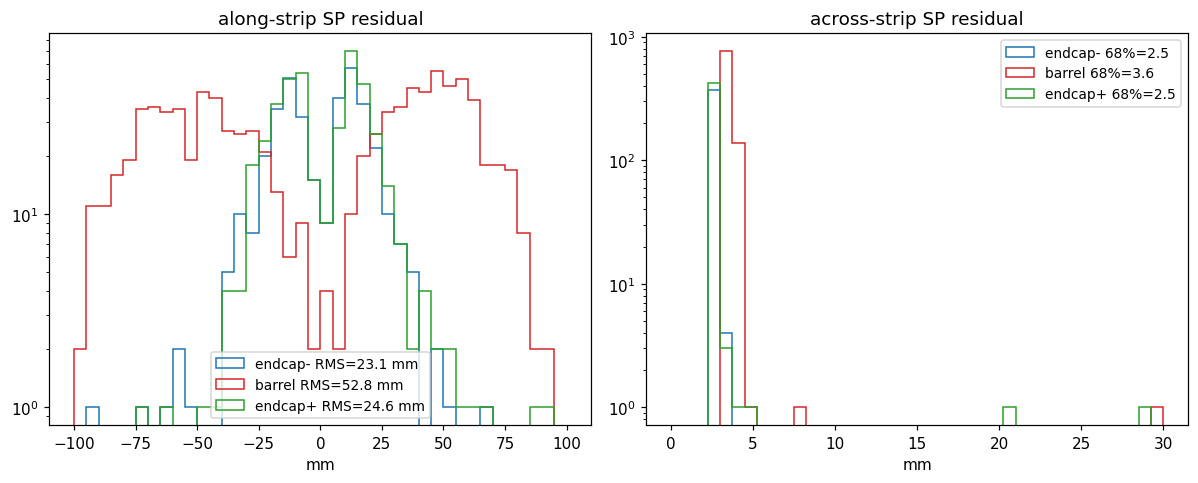

In [12]:

def along_across_resids(records):
    along = []; across = []; vol = []
    for r in records:
        delta = r["sp"] - r["truth_mid"]
        a = float(np.dot(delta, r["d1"]))
        b = float(np.linalg.norm(delta - a*r["d1"]))
        along.append(a); across.append(b); vol.append(r["v"])
    return np.array(along), np.array(across), np.array(vol)

a_along, a_across, a_vol = along_across_resids(records)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for v, lab, color in [(28, "endcap-", "C0"), (29, "barrel", "C3"), (30, "endcap+", "C2")]:
    sel = a_vol == v
    if sel.sum() == 0: continue
    ax[0].hist(a_along[sel], bins=np.linspace(-100, 100, 41),
               histtype="step", label=f"{lab} RMS={a_along[sel].std():.1f} mm", color=color)
    ax[1].hist(a_across[sel], bins=np.linspace(0, 30, 41),
               histtype="step", label=f"{lab} 68%={np.percentile(a_across[sel],68):.1f}", color=color)
ax[0].set_title("along-strip SP residual"); ax[0].set_xlabel("mm")
ax[1].set_title("across-strip SP residual"); ax[1].set_xlabel("mm")
for a in ax: a.legend(fontsize=9); a.set_yscale("log")
plt.tight_layout(); plt.show()



## 13. The 1/sin(theta) amplification - direct check

For a small perpendicular displacement `du` of one strip in its own pitch
direction, the intersection with its (nearly parallel) stereo partner moves
*along* the partner by `dx = du / sin(theta_stereo)`. With ODD's 40 mrad relative
stereo, that's a x25 amplification.

We can measure this directly on the data: scatter the across-strip residual
(typical few um) against the along-strip SP residual (typical tens of mm).
The slope should be ~ 1/sin(40 mrad) ~ 25.


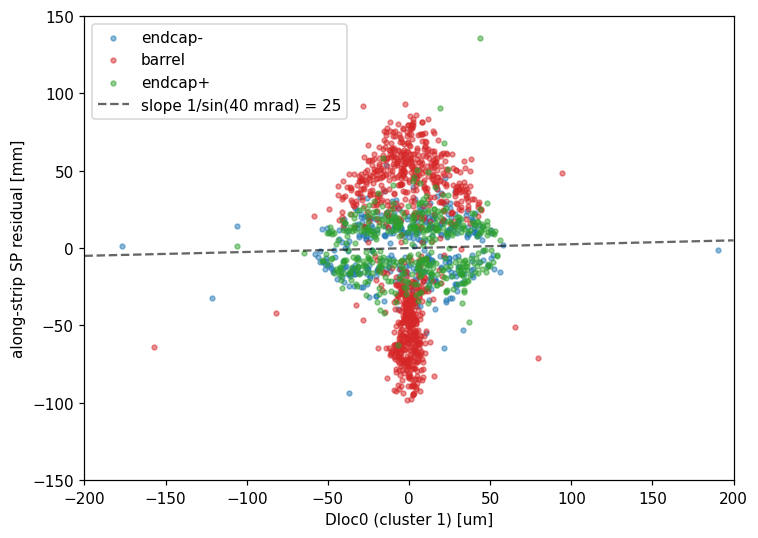

In [13]:

delta_loc0_1 = np.array([m_loc0[r["r1"]] - m_tloc0[r["r1"]] for r in records])
fig, ax = plt.subplots(figsize=(7, 5))
for v, lab, color in [(28, "endcap-", "C0"), (29, "barrel", "C3"), (30, "endcap+", "C2")]:
    sel = a_vol == v
    if sel.sum() == 0: continue
    ax.scatter(delta_loc0_1[sel]*1000, a_along[sel], s=10, alpha=0.5, label=lab, color=color)
ax.set_xlabel("Dloc0 (cluster 1) [um]")
ax.set_ylabel("along-strip SP residual [mm]")
xx = np.linspace(-200, 200, 100)
ax.plot(xx, 25e-3*xx, "k--", alpha=0.6, label="slope 1/sin(40 mrad) = 25")
ax.set_xlim(-200, 200); ax.set_ylim(-150, 150)
ax.legend(); plt.tight_layout(); plt.show()



## 14. Diagnostic helpers - saved here for reuse

A few small utilities to keep with you while debugging.


In [14]:

def explain_pair(row):
    """Print everything we can say about one SP/truth pair."""
    r1, r2 = row["r1"], row["r2"]
    print(f"event {row['e']}, vol {row['v']} lay {row['l']}, surf {row['s1']}<->{row['s2']}, "
          f"extra {row['x1']}<->{row['x2']}")
    print(f"  cluster 1: rec_loc0 = {m_loc0[r1]:+.4f} mm, true_loc0 = {m_tloc0[r1]:+.4f}, true_loc1 = {m_tloc1[r1]:+.2f},  clus_size = {m_clusz[r1]}")
    print(f"  cluster 2: rec_loc0 = {m_loc0[r2]:+.4f} mm, true_loc0 = {m_tloc0[r2]:+.4f}, true_loc1 = {m_tloc1[r2]:+.2f},  clus_size = {m_clusz[r2]}")
    print(f"  Dloc0 (1) = {(m_loc0[r1]-m_tloc0[r1])*1000:+.2f} um    (2) = {(m_loc0[r2]-m_tloc0[r2])*1000:+.2f} um")
    rec1 = np.array([m_gx[r1], m_gy[r1], m_gz[r1]])
    rec2 = np.array([m_gx[r2], m_gy[r2], m_gz[r2]])
    tru1 = np.array([m_tx[r1], m_ty[r1], m_tz[r1]])
    tru2 = np.array([m_tx[r2], m_ty[r2], m_tz[r2]])
    sp_xyz = np.array([sp["x"][row["sp_idx"]], sp["y"][row["sp_idx"]], sp["z"][row["sp_idx"]]])
    truth_mid = 0.5*(tru1 + tru2)
    print(f"  rec_g 1  = {rec1}")
    print(f"  rec_g 2  = {rec2}")
    print(f"  truth 1  = {tru1}")
    print(f"  truth 2  = {tru2}")
    print(f"  truthmid = {truth_mid}")
    print(f"  ACTS SP  = {sp_xyz}")
    print(f"  |SP - truthmid| = {np.linalg.norm(sp_xyz - truth_mid):.2f} mm")

if endcap_pairs:
    print("--- endcap example ---")
    explain_pair(endcap_pairs[0])
if barrel_pairs:
    print("\n--- barrel example ---")
    explain_pair(barrel_pairs[0])


--- endcap example ---
event 1, vol 28 lay 2, surf 162<->161, extra 2<->2
  cluster 1: rec_loc0 = +57.9375 mm, true_loc0 = +57.9250, true_loc1 = +70.81,  clus_size = 1
  cluster 2: rec_loc0 = +61.0549 mm, true_loc0 = +61.0625, true_loc1 = +66.70,  clus_size = 2
  Dloc0 (1) = +12.47 um    (2) = -7.55 um
  rec_g 1  = [  311.88312  -940.155   -3009.5    ]
  rec_g 2  = [  315.50958  -941.647   -3004.5    ]
  truth 1  = [  331.56186 -1008.1741  -3009.5    ]
  truth 2  = [  331.48904 -1006.4081  -3004.5613 ]
  truthmid = [  331.52545 -1007.2911  -3007.0308 ]
  ACTS SP  = [  334.81937 -1019.3813  -3009.5    ]
  |SP - truthmid| = 12.77 mm

--- barrel example ---
event 1, vol 29 lay 2, surf 2496<->2495, extra 0<->0
  cluster 1: rec_loc0 = +9.9741 mm, true_loc0 = +9.9750, true_loc1 = -1.37,  clus_size = 2
  cluster 2: rec_loc0 = +6.5989 mm, true_loc0 = +6.5976, true_loc1 = -7.39,  clus_size = 2
  Dloc0 (1) = -0.91 um    (2) = +1.22 um
  rec_g 1  = [477.19824 672.7465  651.     ]
  rec_g 2  = [47


## 15. How to regenerate fresh outputs

The lock-in full-PU run at `RUN_DIR_FULLPU` is produced by:

1. Symlinking the existing `edm4hep.root` from `full_pileup/ttbar/v1/runs/0`
   into a new `v5/runs/0` (the "do not modify campaign data" rule).
2. Running `digi_and_reco.py` with a yaml that pins
   `debug_output_dir: .../full_pileup/ttbar/v5/runs/0`, plus the lock-in
   pairing knobs:
   ```yaml
   strip_pairing_mode: top_k
   strip_top_k: 4
   strip_length_tolerance: 0.3
   strip_gap_parameter: 0.6
   spacepoint_geometry_selection: scripts/simulation/odd-strip-spacepoint-selection.json
   ```

The hard-scatter sibling config at
`configs_production/hard_scatter/ttbar/digitization_config_v5_spacepoint_test.yaml`
is the closest committed template - copy it, change `campaign` to
`full_pileup` and `debug_output_dir` to the full_pileup tree, then
uncomment the lock-in knobs at the bottom.

Driver invocation (from the `colliderml_dev` repo root):

```bash
# activate the ACTS-bound conda env first; its setup.sh adds the v5 build's
# python/ to PYTHONPATH and sets ICU/Boost/etc paths.
conda activate collider-env
source /global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/acts_versions/acts_v5/build/python/setup.sh
python scripts/simulation/digi_and_reco.py \
    --config configs_production/full_pileup/ttbar/digitization_config_v5_spacepoint_lockin.yaml
```

This emits `{spacepoints, measurements, particles, edm4hep, performance_measurements}.root`
into the configured output dir. After that, point this notebook's
`RUN_DIR` to the same directory and re-run.

The committed `scripts/diagnostics/spacepoint_efficiency.py` analyser can
also be run directly:

```bash
python scripts/diagnostics/spacepoint_efficiency.py \
    --run-dir /global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v5/runs/0
```

## 16. What's still open (plausible debug avenues)

This notebook makes the existing knowns concrete. Open avenues to chase:

* **Cluster-tail clusters that pull Dloc0 to >12 mm.** The 1.14 % residual
  inefficiency is dominated by these. Need a cluster-by-cluster look at
  what kind of multi-particle merges produce them: PU min-bias only?
  Hard-scatter pile-on too? Per-particle-truth-aware splitting (MC-only)
  would set an upper bound.

* **Pitch RMS asymmetry.** Endcap pitch RMS = 373 um vs barrel 537 um
  despite endcap having *more* clusters/sensor (slide 20 backup). Why? Cell
  size? Geant4 step modelling? Charge sharing? Probably a clusterer fix
  rather than an SP fix.

* **3-strip combinations.** Can a third stereo wafer's measurement narrow
  the along-strip ambiguity in barrel? ATLAS strips don't do this; ODD
  *might* allow it in adjacent layers via beamline-constraint rather than
  per-wafer triangulation.

* **Closest-approach SP variant (Option 1 in the slides).** Tried, did not
  improve. Code path lives in `acts_v5/Core/src/SpacePointFormation2/StripSpacePointBuilder.cpp::computeCosmicSpacePoint`.

* **stripGapParameter sensitivity.** Lock-in is 0.6; the slides table at
  `What the formula says...` shows extras of 0.48 (endcap @ 0.3) -> 1.61
  (endcap @ 1.0). Sweep more finely near 0.6 to confirm Pareto-optimality
  on the 32-event hard-scatter sample.

* **Truth-aware cluster splitting.** Path B was rejected because the
  splitter only fires on ~16 / 736k clusters (slide 4). A truth-aware
  variant could be built as a debugging upper-bound.
